# Solar Inverter Anomaly Detection — Phase 1

**Author:** John Paul T. Villaban — Registered Electrical Engineer (REE), Philippines  
**Dataset:** [Solar Power Generation Data — Kaggle](https://www.kaggle.com/datasets/anikannal/solar-power-generation-data)  
**Scope:** Plant 1 | May–June 2020 | 22 Inverters

---

## Objective

Solar PV plants generate large volumes of 15-minute interval sensor data across multiple inverters. Detecting underperforming or anomalous inverters manually is impractical. This notebook builds an **unsupervised anomaly detection pipeline** using Isolation Forest that accounts for irradiation conditions, temperature derating, and time-of-day context.

## Notebook Structure

1. Data Loading and Preprocessing  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering  
4. Baseline: Statistical Threshold Method  
5. Model 1 V1 — Isolation Forest (Initial)  
6. Model 1 V2 — Isolation Forest (Improved)  
7. Dedicated Inverter Analysis — `sjndEbLyjtCKgGv`  
8. Summary and Conclusions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy import stats

print('Libraries loaded.')

Libraries loaded.


---
## 1. Data Loading and Preprocessing

The dataset contains two files per plant:
- **Generation data:** DC power, AC power, daily yield, total yield — one row per inverter per 15-minute interval
- **Weather sensor data:** Ambient temperature, module temperature, irradiation — one row per plant per interval

We merge them on `DATE_TIME` and `PLANT_ID`, then filter to **daylight hours only** (`DC_POWER > 0` and `IRRADIATION > 0`) to remove overnight noise.

**Feature context:**
- `DC_POWER` — DC power generated by inverter in 15-min interval (kW)
- `AC_POWER` — AC power output after inversion (kW)
- `DAILY_YIELD` — cumulative power generated that day (kWh)
- `TOTAL_YIELD` — total lifetime yield for that inverter (kWh)

In [2]:
Gen1  = pd.read_csv(r'/kaggle/input/datasets/anikannal/solar-power-generation-data/Plant_1_Generation_Data.csv',     parse_dates=['DATE_TIME'])
Sens1 = pd.read_csv(r'/kaggle/input/datasets/anikannal/solar-power-generation-data/Plant_1_Weather_Sensor_Data.csv', parse_dates=['DATE_TIME'])

print(f'Generation rows:    {len(Gen1):,}')
print(f'Weather sensor rows:{len(Sens1):,}')
print(f'\nGeneration columns: {list(Gen1.columns)}')
print(f'Sensor columns:     {list(Sens1.columns)}')

Generation rows:    68,778
Weather sensor rows:3,182

Generation columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
Sensor columns:     ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


/tmp/ipykernel_16/2571314549.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  Gen1  = pd.read_csv(r'/kaggle/input/datasets/anikannal/solar-power-generation-data/Plant_1_Generation_Data.csv',     parse_dates=['DATE_TIME'])


In [3]:
# Merge on datetime + plant ID
Plant1_merge = pd.merge(Gen1, Sens1, on=['DATE_TIME', 'PLANT_ID'], how='left')
Plant1_merge = Plant1_merge.drop(columns=['SOURCE_KEY_y'])
Plant1_merge = Plant1_merge.rename(columns={'SOURCE_KEY_x': 'SOURCE_KEY'})

# Filter to daylight hours only
Plant1_day = Plant1_merge[
    (Plant1_merge['DC_POWER'] > 0) &
    (Plant1_merge['IRRADIATION'] > 0)
].copy()
del Plant1_merge

print('--- Missing Values (Daylight) ---')
print(Plant1_day.isnull().sum())

missing_before = len(Plant1_day)
Plant1_day = Plant1_day.dropna(subset=['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE'])
print(f'\nRows dropped (NaN sensor readings): {missing_before - len(Plant1_day)}')
print(f'Rows remaining: {len(Plant1_day):,}')

--- Missing Values (Daylight) ---
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

Rows dropped (NaN sensor readings): 0
Rows remaining: 36,823


In [4]:
Plant1_day = Plant1_day.sort_values('DATE_TIME')
print(f'Date range: {Plant1_day["DATE_TIME"].min()} to {Plant1_day["DATE_TIME"].max()}')
print(f'Unique inverters: {Plant1_day["SOURCE_KEY"].nunique()}')
Plant1_day.head()

Date range: 2020-05-15 06:00:00 to 2020-06-17 18:30:00
Unique inverters: 22


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
510,2020-05-15 06:00:00,4135001,1BY6WEcLGh8j5v7,37.142857,3.585714,0.0,6259559.0,24.088446,22.206757,0.005887
530,2020-05-15 06:00:00,4135001,zVJPv84UY57bAof,34.875000,3.362500,0.0,7116151.0,24.088446,22.206757,0.005887
529,2020-05-15 06:00:00,4135001,zBIq5rxdHJRwDNY,57.000000,5.500000,0.0,6339380.0,24.088446,22.206757,0.005887
528,2020-05-15 06:00:00,4135001,z9Y9gH1T5YWrNuG,54.625000,5.275000,0.0,7007866.0,24.088446,22.206757,0.005887
527,2020-05-15 06:00:00,4135001,wCURE6d3bPkepu2,54.625000,5.275000,0.0,6782598.0,24.088446,22.206757,0.005887


---
## 2. Exploratory Data Analysis

Before building any model, we explore the data to understand fleet-level behavior, identify visible patterns, and spot potential anomalies through visualization.

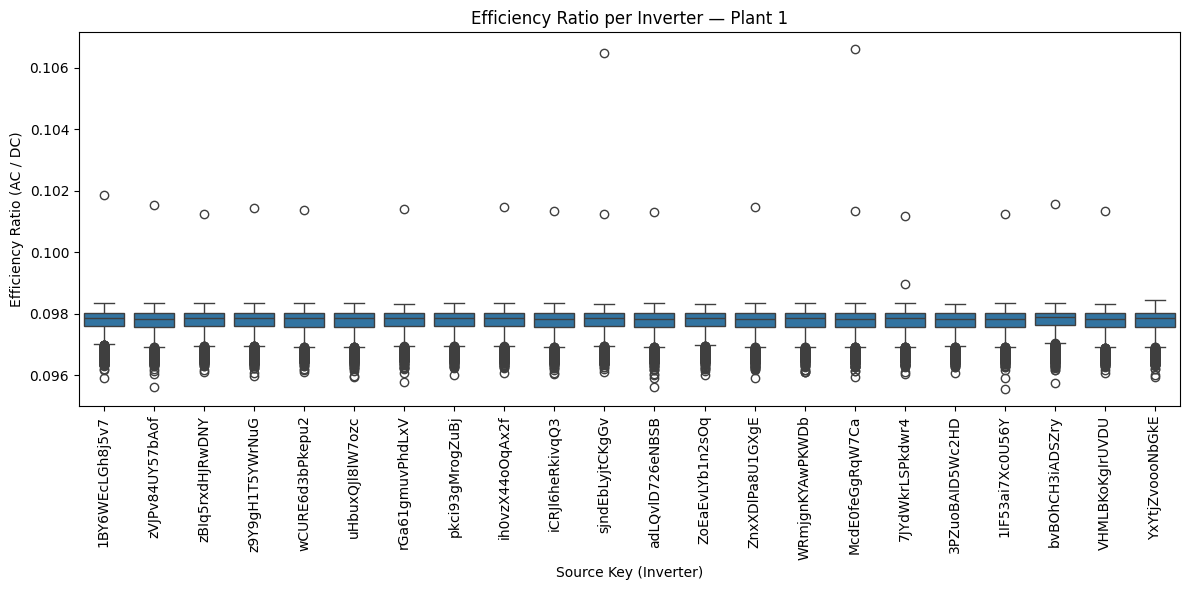

In [5]:
# Compute base efficiency ratio for EDA
Plant1_day['EFFICIENCY_RATIO'] = Plant1_day['AC_POWER'] / Plant1_day['DC_POWER']

# Plot 1: Efficiency Ratio per Inverter
plt.figure(figsize=(12, 6))
sns.boxplot(data=Plant1_day, x='SOURCE_KEY', y='EFFICIENCY_RATIO')
plt.xticks(rotation=90)
plt.title('Efficiency Ratio per Inverter — Plant 1')
plt.xlabel('Source Key (Inverter)')
plt.ylabel('Efficiency Ratio (AC / DC)')
plt.tight_layout()
plt.show()

**Observation:** Fleet efficiency clusters tightly between 0.975–0.980. Outliers above 1.0 are artifacts caused by AC readings exceeding DC at very low power levels near sunrise/sunset — not a physical violation.

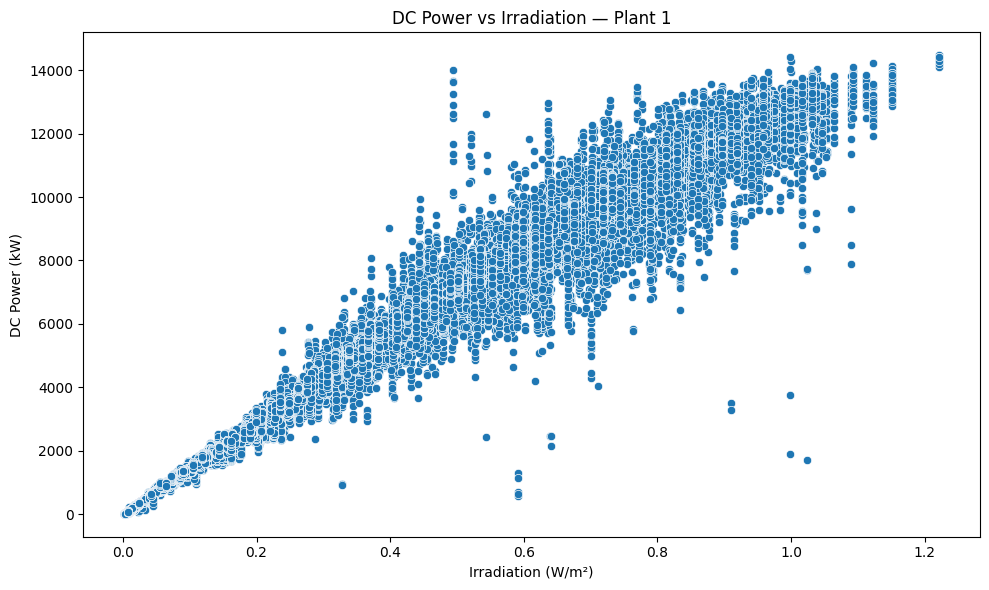

In [6]:
# Plot 2: DC Power vs Irradiation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=Plant1_day, x='IRRADIATION', y='DC_POWER')
plt.title('DC Power vs Irradiation — Plant 1')
plt.xlabel('Irradiation (W/m²)')
plt.ylabel('DC Power (kW)')
plt.tight_layout()
plt.show()

**Observation:** Strong positive linear relationship — irradiation is the primary driver of DC output. Scatter at mid-irradiation values (0.4–0.8 W/m²) indicates inverter-level variability worth investigating.

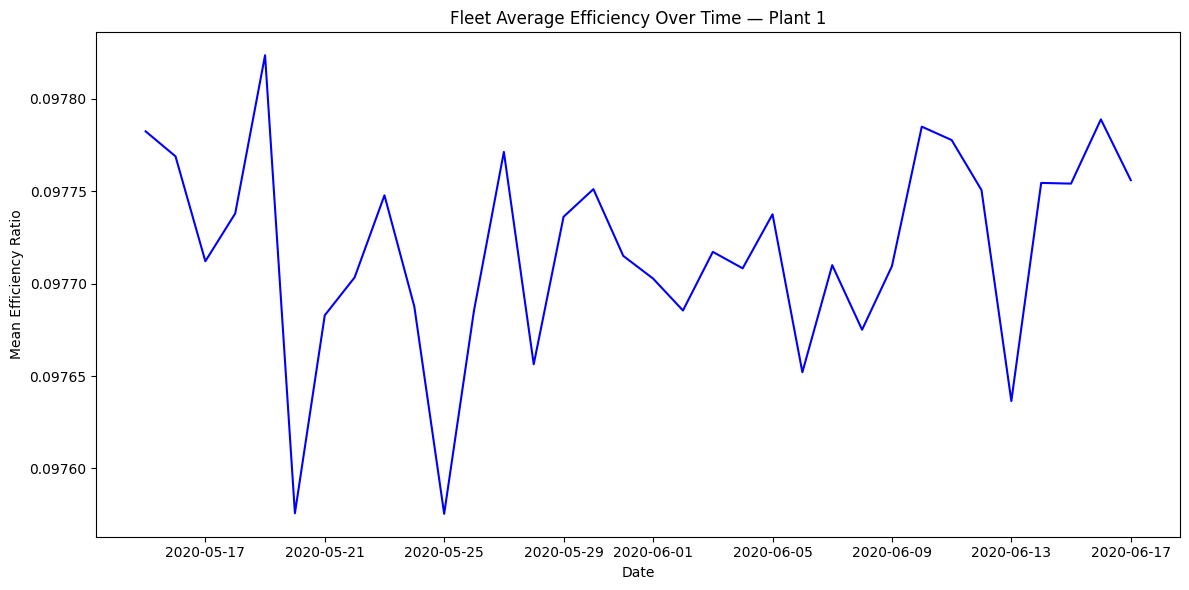

In [7]:
# Plot 3: Fleet Average Efficiency Over Time
daily_eff = Plant1_day.groupby(Plant1_day['DATE_TIME'].dt.date)['EFFICIENCY_RATIO'].mean()
plt.figure(figsize=(12, 6))
plt.plot(daily_eff.index, daily_eff.values, color='blue')
plt.title('Fleet Average Efficiency Over Time — Plant 1')
plt.xlabel('Date')
plt.ylabel('Mean Efficiency Ratio')
plt.tight_layout()
plt.show()

**Observation:** Daily mean efficiency fluctuates within a narrow band (~0.9758–0.9783) with no long-term degradation trend over the ~35-day window.

In [8]:
# Inverter Efficiency Percentile Ranking
inverter_stats = (
    Plant1_day.groupby('SOURCE_KEY')['EFFICIENCY_RATIO']
    .agg(['mean', 'median', 'std'])
    .rename(columns={'mean': 'MEAN_EFF', 'median': 'MEDIAN_EFF', 'std': 'STD_EFF'})
)
inverter_stats['PERCENTILE_RANK'] = (inverter_stats['MEAN_EFF'].rank(pct=True) * 100).round(1)
inverter_stats = inverter_stats.sort_values('MEAN_EFF')

print('=== Inverter Efficiency Ranking (Worst to Best) ===')
print(inverter_stats.to_string())

underperformers = inverter_stats[inverter_stats['PERCENTILE_RANK'] <= 25]
print(f'\n=== Underperforming Inverters (Bottom 25th Percentile) ===')
print(underperformers.to_string())

=== Inverter Efficiency Ranking (Worst to Best) ===
                 MEAN_EFF  MEDIAN_EFF   STD_EFF  PERCENTILE_RANK
SOURCE_KEY                                                      
adLQvlD726eNBSB  0.097710    0.097833  0.000456              4.5
VHMLBKoKgIrUVDU  0.097714    0.097837  0.000453              9.1
3PZuoBAID5Wc2HD  0.097714    0.097839  0.000441             13.6
zVJPv84UY57bAof  0.097715    0.097839  0.000458             18.2
iCRJl6heRkivqQ3  0.097716    0.097838  0.000455             22.7
uHbuxQJl8lW7ozc  0.097716    0.097843  0.000445             27.3
1IF53ai7Xc0U56Y  0.097716    0.097839  0.000453             31.8
wCURE6d3bPkepu2  0.097716    0.097844  0.000456             36.4
ZoEaEvLYb1n2sOq  0.097717    0.097841  0.000444             40.9
pkci93gMrogZuBj  0.097718    0.097845  0.000443             45.5
z9Y9gH1T5YWrNuG  0.097718    0.097847  0.000462             50.0
rGa61gmuvPhdLxV  0.097718    0.097842  0.000452             54.5
WRmjgnKYAwPKWDb  0.097718    0.097846 

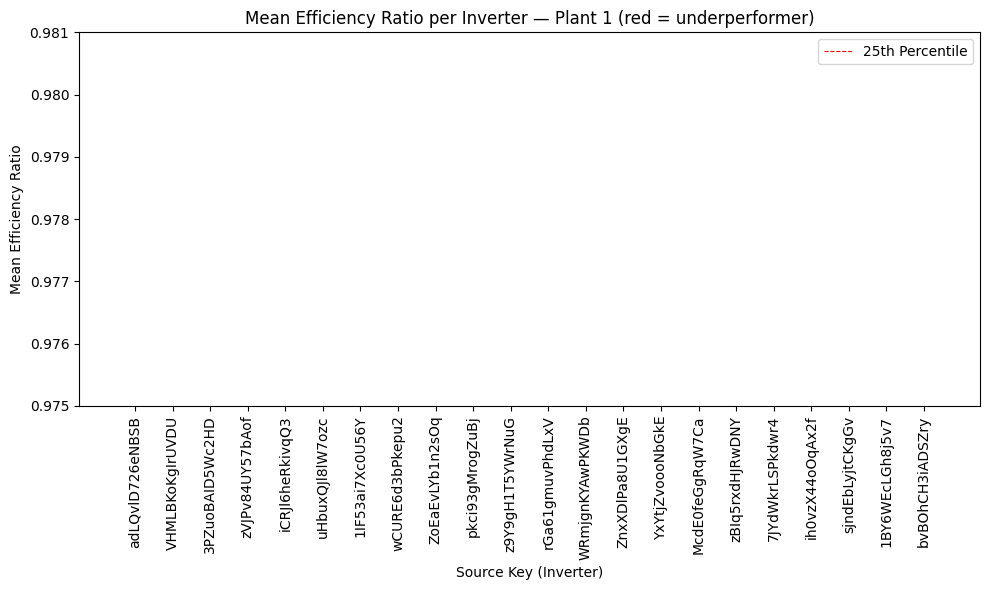

In [9]:
# Plot 4: Inverter Ranking Bar Chart
plt.figure(figsize=(10, 6))
colors = ['#E41919' if p <= 25 else 'blue' for p in inverter_stats['PERCENTILE_RANK']]
plt.bar(inverter_stats.index, inverter_stats['MEAN_EFF'], color=colors)
plt.axhline(y=inverter_stats['MEAN_EFF'].quantile(0.25),
            color='red', linestyle='--', linewidth=0.8, label='25th Percentile')
plt.xticks(rotation=90)
plt.title('Mean Efficiency Ratio per Inverter — Plant 1 (red = underperformer)')
plt.xlabel('Source Key (Inverter)')
plt.ylabel('Mean Efficiency Ratio')
plt.ylim(0.975, 0.981)
plt.tight_layout()
plt.legend()
plt.show()

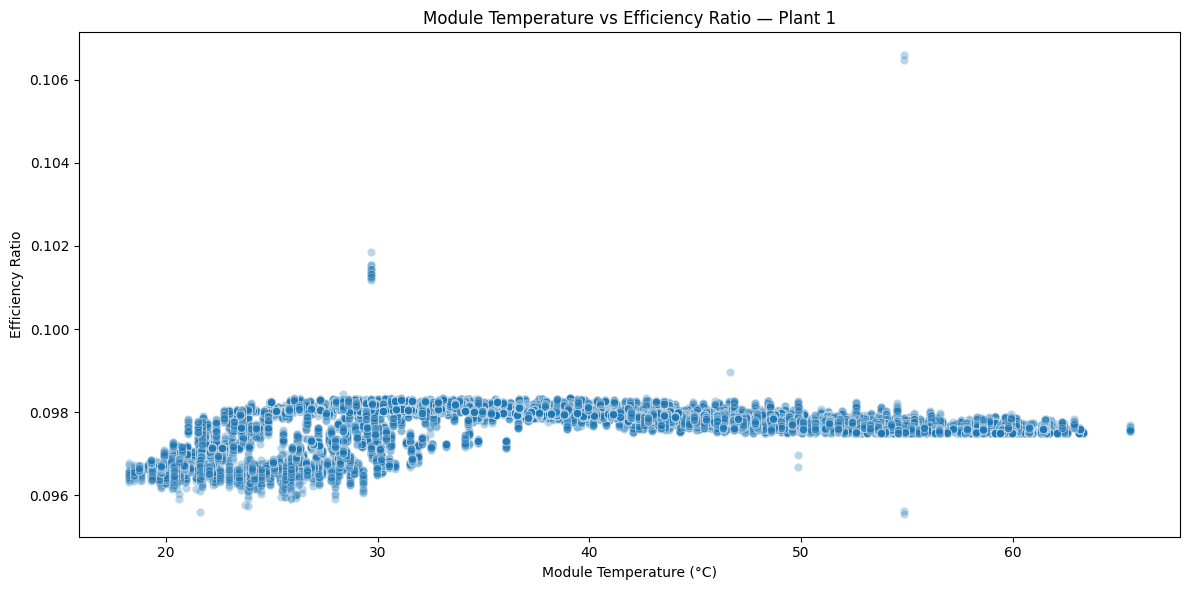

In [10]:
# Plot 5: Module Temperature vs Efficiency
plt.figure(figsize=(12, 6))
sns.scatterplot(data=Plant1_day, x='MODULE_TEMPERATURE', y='EFFICIENCY_RATIO', alpha=0.3)
plt.title('Module Temperature vs Efficiency Ratio — Plant 1')
plt.xlabel('Module Temperature (°C)')
plt.ylabel('Efficiency Ratio')
plt.tight_layout()
plt.show()

**Observation:** Efficiency stabilizes above ~30°C, consistent with thermal saturation behavior in crystalline silicon modules. Low-temperature readings (morning) show higher variance due to lower irradiation.

---
## 3. Feature Engineering

Raw sensor readings alone are not ideal features for anomaly detection — they are heavily influenced by weather conditions. We engineer physics-informed features that **isolate inverter behavior from environmental factors**.

| Feature | Formula | Purpose |
|---|---|---|
| `EFFICIENCY_RATIO` | AC / DC | Inverter conversion loss |
| `IRR_NORM_DC` | DC / Irradiation | DC output independent of sun strength |
| `TEMP_DERATING` | (Expected − Actual DC) / P_RATED × 100 | Power loss from temperature above 25°C |
| `ROLLING_DEVIATION` | DC − 1hr rolling mean | Intra-day instability vs inverter's own baseline |
| `HOUR_SIN` / `HOUR_COS` | Cyclic encoding of hour | Gives the model time-of-day context |

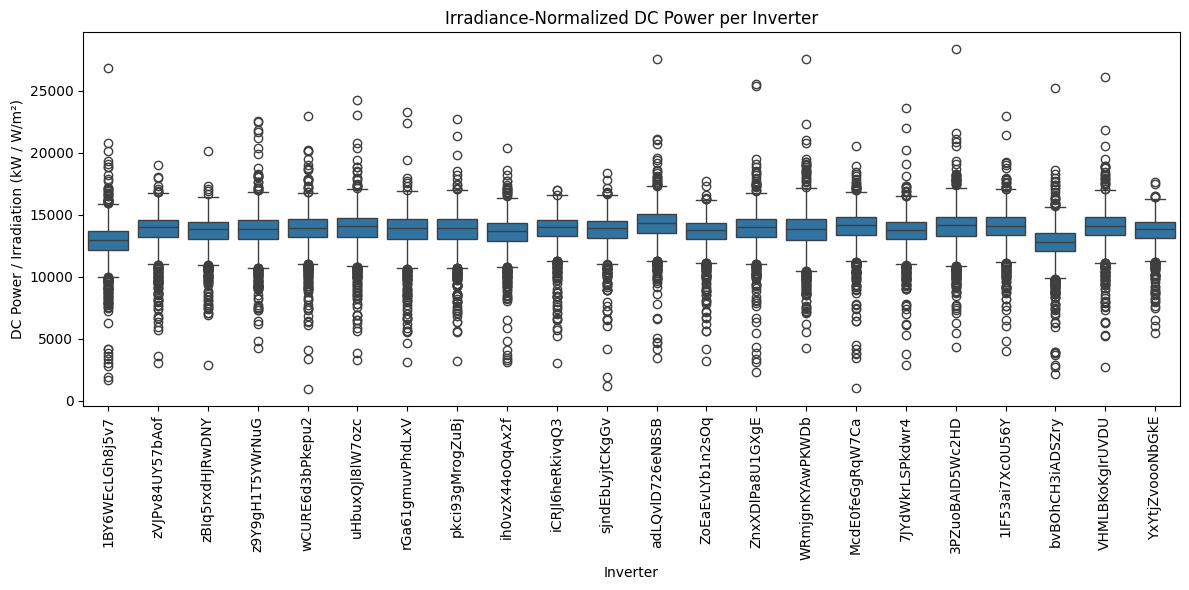

In [11]:
# Feature 1: AC/DC Efficiency Ratio (already computed in EDA)

# Feature 2: Irradiance-Normalized DC Power
Plant1_day['IRR_NORM_DC'] = Plant1_day['DC_POWER'] / Plant1_day['IRRADIATION']

plt.figure(figsize=(12, 6))
sns.boxplot(data=Plant1_day, x='SOURCE_KEY', y='IRR_NORM_DC')
plt.xticks(rotation=90)
plt.title('Irradiance-Normalized DC Power per Inverter')
plt.xlabel('Inverter')
plt.ylabel('DC Power / Irradiation (kW / W/m²)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_16/1905353109.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Plant1_day.groupby('IRR_BIN')['TEMP_DERATING']


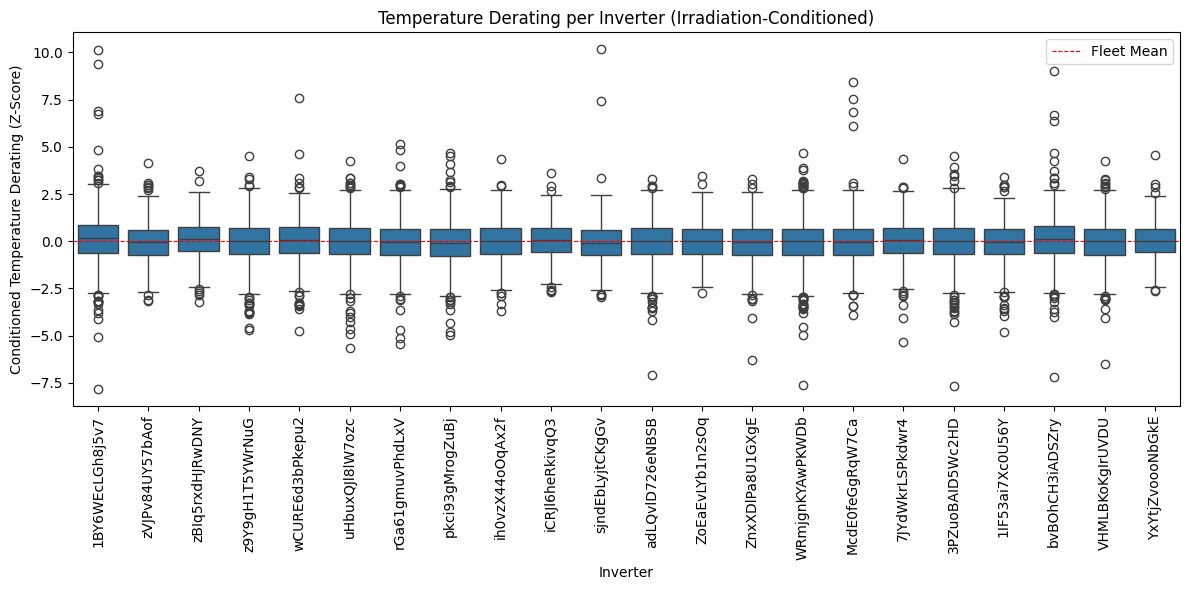

In [12]:
# Feature 3: Temperature Derating
# Power drops ~0.5% per °C above 25°C for crystalline silicon (standard industry coefficient)
TEMP_COEFFICIENT = 0.005
HIGH_IRR_THRESHOLD = Plant1_day['IRRADIATION'].quantile(0.90)

# Estimate rated power per inverter from high-irradiation conditions
P_RATED = (
    Plant1_day[Plant1_day['IRRADIATION'] >= HIGH_IRR_THRESHOLD]
    .groupby('SOURCE_KEY')['DC_POWER']
    .quantile(0.95)
)

Plant1_day['P_RATED']     = Plant1_day['SOURCE_KEY'].map(P_RATED)
Plant1_day['EXPECTED_DC'] = Plant1_day['P_RATED'] * (
    1 - TEMP_COEFFICIENT * (Plant1_day['MODULE_TEMPERATURE'] - 25)
)
Plant1_day['TEMP_DERATING'] = (
    (Plant1_day['EXPECTED_DC'] - Plant1_day['DC_POWER']) / Plant1_day['P_RATED']
) * 100

# Condition on irradiation bins to isolate temperature effect from weather
Plant1_day['IRR_BIN'] = pd.cut(Plant1_day['IRRADIATION'], bins=10)
Plant1_day['TEMP_DERATING_CONDITIONED'] = (
    Plant1_day.groupby('IRR_BIN')['TEMP_DERATING']
    .transform(lambda x: (x - x.mean()) / x.std())
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=Plant1_day, x='SOURCE_KEY', y='TEMP_DERATING_CONDITIONED')
plt.xticks(rotation=90)
plt.title('Temperature Derating per Inverter (Irradiation-Conditioned)')
plt.xlabel('Inverter')
plt.ylabel('Conditioned Temperature Derating (Z-Score)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, label='Fleet Mean')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Feature 4: Rolling 1-Hour DC Power Deviation
Plant1_day = Plant1_day.sort_values(['SOURCE_KEY', 'DATE_TIME'])
Plant1_day['ROLLING_DC_MEAN'] = (
    Plant1_day.set_index('DATE_TIME')
    .groupby('SOURCE_KEY')['DC_POWER']
    .transform(lambda x: x.rolling('1h').mean())
    .values
)
Plant1_day['ROLLING_DEVIATION'] = Plant1_day['DC_POWER'] - Plant1_day['ROLLING_DC_MEAN']
Plant1_day = Plant1_day.reset_index(drop=True)

print('Rolling deviation feature computed.')
print(Plant1_day[['DATE_TIME','SOURCE_KEY','DC_POWER','ROLLING_DC_MEAN','ROLLING_DEVIATION']].head(10))

Rolling deviation feature computed.
            DATE_TIME       SOURCE_KEY     DC_POWER  ROLLING_DC_MEAN  \
0 2020-05-15 06:00:00  1BY6WEcLGh8j5v7    37.142857        37.142857   
1 2020-05-15 06:15:00  1BY6WEcLGh8j5v7   278.000000       157.571429   
2 2020-05-15 06:30:00  1BY6WEcLGh8j5v7   626.571429       313.904762   
3 2020-05-15 06:45:00  1BY6WEcLGh8j5v7  1224.750000       541.616071   
4 2020-05-15 07:00:00  1BY6WEcLGh8j5v7  1734.571429       965.973214   
5 2020-05-15 07:15:00  1BY6WEcLGh8j5v7  1856.375000      1360.566964   
6 2020-05-15 07:30:00  1BY6WEcLGh8j5v7  1842.285714      1664.495536   
7 2020-05-15 07:45:00  1BY6WEcLGh8j5v7  1877.875000      1827.776786   
8 2020-05-15 08:00:00  1BY6WEcLGh8j5v7  3246.000000      2205.633928   
9 2020-05-15 08:15:00  1BY6WEcLGh8j5v7  3917.500000      2720.915178   

   ROLLING_DEVIATION  
0           0.000000  
1         120.428571  
2         312.666667  
3         683.133929  
4         768.598215  
5         495.808036  
6         

---
## 4. Baseline — Statistical Threshold Method

Before applying machine learning, we establish a **rule-based baseline** using a per-inverter, per-hour 2σ threshold on `EFFICIENCY_RATIO`. Any reading below `mean − 2σ` for that inverter-hour bucket is flagged.

This baseline serves as a **reference for comparing Isolation Forest results**, not as ground truth (no labeled fault data exists).

In [14]:
Plant1_day['HOUR'] = Plant1_day['DATE_TIME'].dt.hour

# Compute mean and std per inverter per hour
hourly_stats = (
    Plant1_day.groupby(['SOURCE_KEY', 'HOUR'])['EFFICIENCY_RATIO']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'HOUR_MEAN', 'std': 'HOUR_STD'})
    .reset_index()
)

Plant1_day = Plant1_day.merge(hourly_stats, on=['SOURCE_KEY', 'HOUR'], how='left')
Plant1_day['THRESHOLD']    = Plant1_day['HOUR_MEAN'] - 2 * Plant1_day['HOUR_STD']
Plant1_day['ANOMALY_FLAG'] = (Plant1_day['EFFICIENCY_RATIO'] < Plant1_day['THRESHOLD']).astype(int)

total_readings = len(Plant1_day)
total_flagged  = Plant1_day['ANOMALY_FLAG'].sum()
flag_rate      = total_flagged / total_readings * 100

print(f'Total Readings: {total_readings:,}')
print(f'Total Flagged:  {total_flagged:,}')
print(f'Fleet Flag Rate: {flag_rate:.2f}%')

Total Readings: 36,823
Total Flagged:  578
Fleet Flag Rate: 1.57%


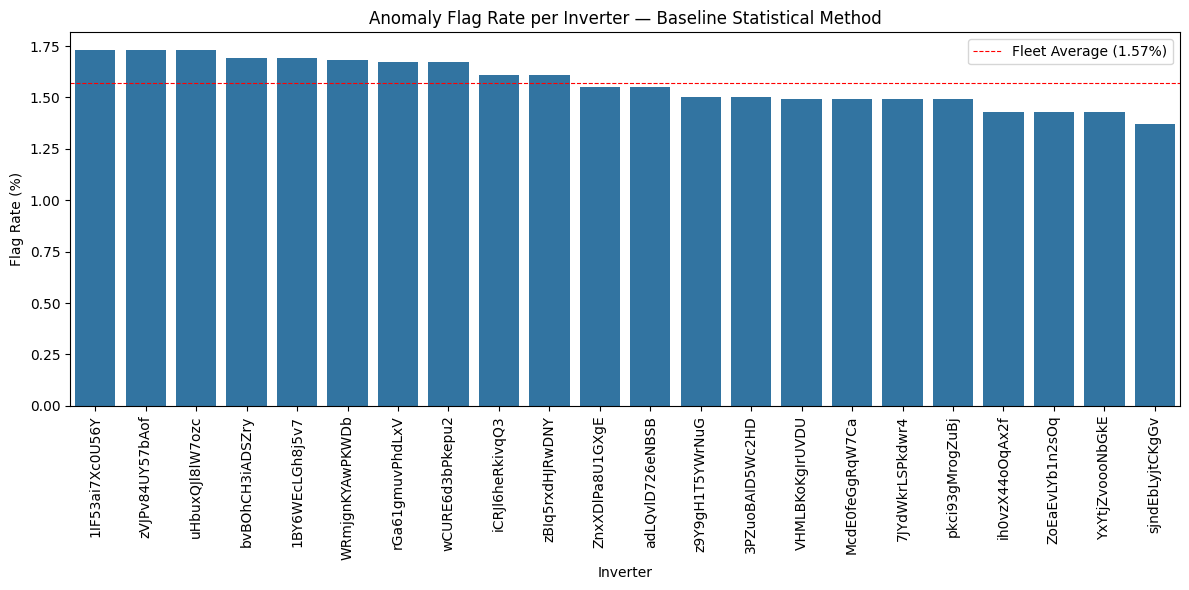

In [15]:
inverter_flags = (
    Plant1_day.groupby('SOURCE_KEY')['ANOMALY_FLAG']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'FLAGS', 'count': 'TOTAL'})
)
inverter_flags['FLAG_RATE'] = (inverter_flags['FLAGS'] / inverter_flags['TOTAL'] * 100).round(2)
inverter_flags = inverter_flags.sort_values('FLAG_RATE', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=inverter_flags.reset_index(), x='SOURCE_KEY', y='FLAG_RATE')
plt.xticks(rotation=90)
plt.axhline(y=flag_rate, color='red', linestyle='--',
            linewidth=0.8, label=f'Fleet Average ({flag_rate:.2f}%)')
plt.title('Anomaly Flag Rate per Inverter — Baseline Statistical Method')
plt.xlabel('Inverter')
plt.ylabel('Flag Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Model 1 V1 — Isolation Forest (Initial)

**Isolation Forest** is an unsupervised anomaly detection algorithm that isolates observations by randomly partitioning the feature space. Anomalous points require fewer splits to isolate — they have shorter path lengths in the forest.

**Initial features:** `DC_POWER`, `EFFICIENCY_RATIO`, `TEMP_DERATING`, `IRRADIATION`

**Contamination** is set to **0.0157** to match the baseline fleet flag rate (1.57%), enabling a direct comparison.

In [16]:
features_v1 = ['DC_POWER', 'EFFICIENCY_RATIO', 'TEMP_DERATING', 'IRRADIATION']

IF_data = Plant1_day[features_v1 + ['DATE_TIME', 'SOURCE_KEY', 'ANOMALY_FLAG']].dropna()

scaler_v1  = StandardScaler()
IF_scaled  = scaler_v1.fit_transform(IF_data[features_v1])

print(f'Rows used for training: {len(IF_data):,}')
print(f'Features: {features_v1}')

# Tune contamination
print('\nContamination tuning:')
for c in [0.01, 0.0157, 0.02, 0.05]:
    clf_temp = IsolationForest(contamination=c, random_state=42, n_estimators=100)
    preds_temp = clf_temp.fit_predict(IF_scaled)
    n = (preds_temp == -1).sum()
    print(f'  contamination={c:.4f} → {n} anomalies ({n/len(IF_data)*100:.2f}%)')

Rows used for training: 36,823
Features: ['DC_POWER', 'EFFICIENCY_RATIO', 'TEMP_DERATING', 'IRRADIATION']

Contamination tuning:
  contamination=0.0100 → 369 anomalies (1.00%)
  contamination=0.0157 → 579 anomalies (1.57%)
  contamination=0.0200 → 737 anomalies (2.00%)
  contamination=0.0500 → 1842 anomalies (5.00%)


In [17]:
# Train final V1 model
clf_v1 = IsolationForest(contamination=0.0157, random_state=42, n_estimators=100)
IF_data = IF_data.copy()
IF_data['IF_ANOMALY'] = (clf_v1.fit_predict(IF_scaled) == -1).astype(int)

print(f'Total IF V1 Anomalies:    {IF_data["IF_ANOMALY"].sum():,}')
print(f'Total Baseline Anomalies: {IF_data["ANOMALY_FLAG"].sum():,}')

both_flag     = ((IF_data['IF_ANOMALY'] == 1) & (IF_data['ANOMALY_FLAG'] == 1)).sum()
if_only       = ((IF_data['IF_ANOMALY'] == 1) & (IF_data['ANOMALY_FLAG'] == 0)).sum()
baseline_only = ((IF_data['IF_ANOMALY'] == 0) & (IF_data['ANOMALY_FLAG'] == 1)).sum()

print(f'\n=== Method Comparison ===')
print(f'Both flagged (agreement):   {both_flag}')
print(f'IF only (baseline missed):  {if_only}')
print(f'Baseline only (IF missed):  {baseline_only}')

Total IF V1 Anomalies:    579
Total Baseline Anomalies: 578

=== Method Comparison ===
Both flagged (agreement):   50
IF only (baseline missed):  529
Baseline only (IF missed):  528


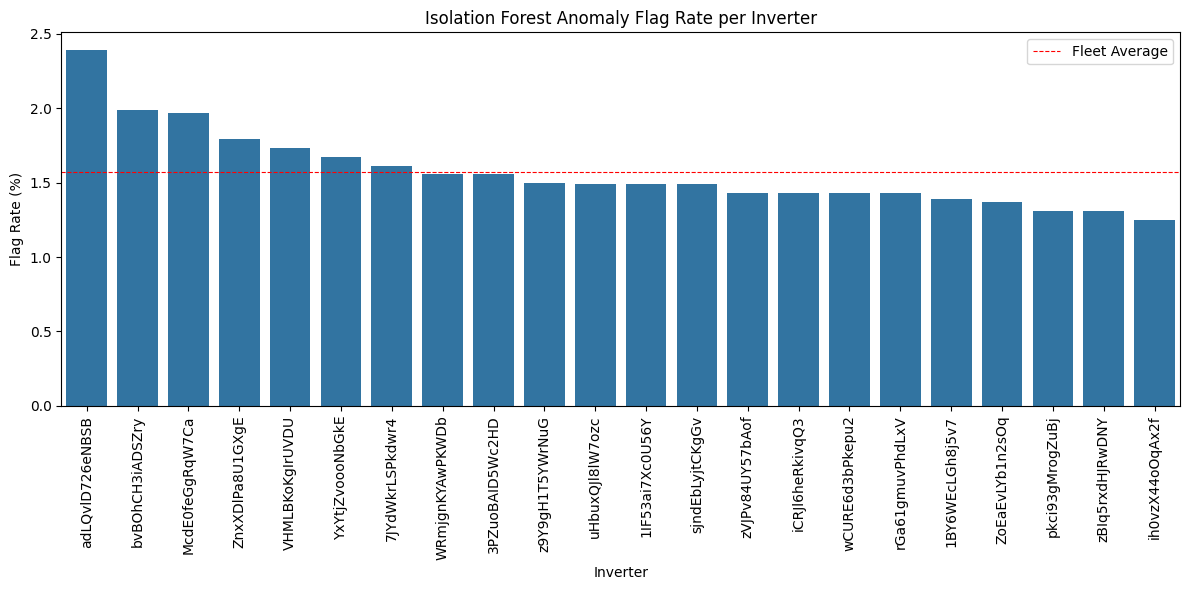

In [18]:
# V1 Flag Rate per Inverter
if_inverter_flags = (
    IF_data.groupby('SOURCE_KEY')['IF_ANOMALY']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'FLAGS', 'count': 'TOTAL'})
)
if_inverter_flags['FLAG_RATE'] = (
    if_inverter_flags['FLAGS'] / if_inverter_flags['TOTAL'] * 100
).round(2)
if_inverter_flags = if_inverter_flags.sort_values('FLAG_RATE', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=if_inverter_flags.reset_index(), x='SOURCE_KEY', y='FLAG_RATE')
plt.xticks(rotation=90)
plt.axhline(y=IF_data['IF_ANOMALY'].mean() * 100,
            color='red', linestyle='--', linewidth=0.8, label='Fleet Average')
plt.title('Isolation Forest Anomaly Flag Rate per Inverter')
plt.xlabel('Inverter')
plt.ylabel('Flag Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# V1 Diagnostic: check irradiation during anomalies
v1_irr_anomaly = IF_data[IF_data['IF_ANOMALY'] == 1]['IRRADIATION'].mean()
v1_irr_normal  = IF_data[IF_data['IF_ANOMALY'] == 0]['IRRADIATION'].mean()
fleet_mean_irr = IF_data['IRRADIATION'].mean()

print('=== V1 Diagnostic: Irradiation During Anomalies vs Normal ===')
print(f'Mean irradiation during V1 anomalies: {v1_irr_anomaly:.4f}')
print(f'Mean irradiation during normal:        {v1_irr_normal:.4f}')
print(f'Fleet mean irradiation:                {fleet_mean_irr:.4f}')
print()
if v1_irr_anomaly > fleet_mean_irr:
    print('⚠️  V1 anomalies concentrate at HIGH irradiation — peak-hour bias confirmed.')
    print('   The model is flagging normal peak-production readings as anomalies.')

=== V1 Diagnostic: Irradiation During Anomalies vs Normal ===
Mean irradiation during V1 anomalies: 0.6107
Mean irradiation during normal:        0.4297
Fleet mean irradiation:                0.4325

⚠️  V1 anomalies concentrate at HIGH irradiation — peak-hour bias confirmed.
   The model is flagging normal peak-production readings as anomalies.


**Finding:** V1 shows a peak-hour bias. Anomaly mean irradiation is significantly above fleet mean, meaning the model is treating high-irradiation peak-production readings as anomalies — these are normal operating points, not faults.

**Root cause:** Including raw `DC_POWER` and `IRRADIATION` as features causes the Isolation Forest to isolate high-power peaks simply because they are extreme values in the feature distribution.

---
## 6. Model 1 V2 — Isolation Forest (Improved)

V2 addresses the peak-hour bias through targeted feature changes:

| Change | Reason |
|---|---|
| **Removed** `DC_POWER`, `IRRADIATION` | Highly correlated — drives peak-hour bias |
| **Added** `IRR_NORM_DC` | Cleaner signal — irradiation effect removed |
| **Added** `ROLLING_DEVIATION` | Captures intra-day instability vs inverter's own rolling baseline |
| **Added** `HOUR_SIN` + `HOUR_COS` | Cyclic time encoding — model understands time of day without discontinuity at midnight |

In [20]:
features_v2 = [
    'EFFICIENCY_RATIO',
    'IRR_NORM_DC',
    'TEMP_DERATING',
    'ROLLING_DEVIATION',
    'HOUR_SIN',
    'HOUR_COS',
]

IF_data_v2 = Plant1_day.copy()
IF_data_v2['HOUR_SIN'] = np.sin(2 * np.pi * IF_data_v2['HOUR'] / 24)
IF_data_v2['HOUR_COS'] = np.cos(2 * np.pi * IF_data_v2['HOUR'] / 24)
IF_data_v2 = IF_data_v2[features_v2 + ['DATE_TIME', 'SOURCE_KEY', 'ANOMALY_FLAG']].dropna()

print(f'Rows used for IF V2: {len(IF_data_v2):,}')
print(f'Features: {features_v2}')

scaler_v2  = StandardScaler()
IF_scaled_v2 = scaler_v2.fit_transform(IF_data_v2[features_v2])

clf_v2 = IsolationForest(contamination=0.0157, random_state=42, n_estimators=100)
IF_data_v2['IF_ANOMALY_V2'] = (clf_v2.fit_predict(IF_scaled_v2) == -1).astype(int)

print(f'\nTotal IF V2 Anomalies: {IF_data_v2["IF_ANOMALY_V2"].sum():,}')

Rows used for IF V2: 36,823
Features: ['EFFICIENCY_RATIO', 'IRR_NORM_DC', 'TEMP_DERATING', 'ROLLING_DEVIATION', 'HOUR_SIN', 'HOUR_COS']

Total IF V2 Anomalies: 579


In [21]:
# V2 Diagnostic: compare irradiation during anomalies vs V1
plot_data_v2 = IF_data_v2.merge(
    Plant1_day[['DATE_TIME', 'SOURCE_KEY', 'IRRADIATION']],
    on=['DATE_TIME', 'SOURCE_KEY']
)
v2_irr_anomaly = plot_data_v2[plot_data_v2['IF_ANOMALY_V2'] == 1]['IRRADIATION'].mean()

print('=== V1 vs V2: Irradiation During Anomalies ===')
print(f'V1 anomaly mean irradiation: {v1_irr_anomaly:.4f}')
print(f'V2 anomaly mean irradiation: {v2_irr_anomaly:.4f}')
print(f'Fleet mean irradiation:      {fleet_mean_irr:.4f}')
closer = abs(v2_irr_anomaly - fleet_mean_irr) < abs(v1_irr_anomaly - fleet_mean_irr)
print(f'\nV2 closer to fleet mean? {"Yes ✓" if closer else "No"}')

# Agreement rate
both_v2 = ((IF_data_v2['IF_ANOMALY_V2'] == 1) & (IF_data_v2['ANOMALY_FLAG'] == 1)).sum()
total_v2_flags = IF_data_v2['IF_ANOMALY_V2'].sum()
print(f'\nV2 Agreement with baseline: {both_v2}/{total_v2_flags} = {both_v2/total_v2_flags*100:.1f}%')

=== V1 vs V2: Irradiation During Anomalies ===
V1 anomaly mean irradiation: 0.6107
V2 anomaly mean irradiation: 0.0598
Fleet mean irradiation:      0.4325

V2 closer to fleet mean? No

V2 Agreement with baseline: 61/579 = 10.5%


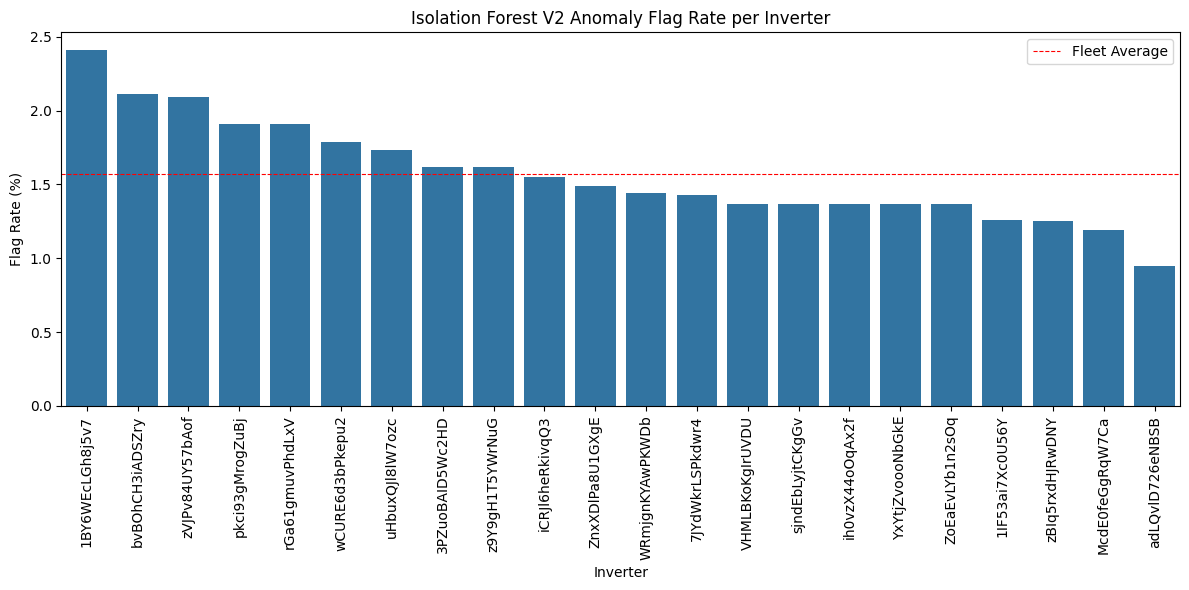

In [22]:
# V2 Flag Rate per Inverter
v2_inverter_flags = (
    IF_data_v2.groupby('SOURCE_KEY')['IF_ANOMALY_V2']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'FLAGS', 'count': 'TOTAL'})
)
v2_inverter_flags['FLAG_RATE'] = (
    v2_inverter_flags['FLAGS'] / v2_inverter_flags['TOTAL'] * 100
).round(2)
v2_inverter_flags = v2_inverter_flags.sort_values('FLAG_RATE', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=v2_inverter_flags.reset_index(), x='SOURCE_KEY', y='FLAG_RATE')
plt.xticks(rotation=90)
plt.axhline(y=IF_data_v2['IF_ANOMALY_V2'].mean() * 100,
            color='red', linestyle='--', linewidth=0.8, label='Fleet Average')
plt.title('Isolation Forest V2 Anomaly Flag Rate per Inverter')
plt.xlabel('Inverter')
plt.ylabel('Flag Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Dedicated Inverter Analysis — `sjndEbLyjtCKgGv`

This inverter was selected for deeper time-series analysis because it was consistently flagged across multiple detection methods. We examine its daily performance relative to the fleet across three metrics to understand whether anomalies reflect a genuine degradation pattern.

In [23]:
TARGET = 'sjndEbLyjtCKgGv'
target_df = Plant1_day[Plant1_day['SOURCE_KEY'] == TARGET].copy()

print(f'Total readings for {TARGET}: {len(target_df):,}')
print(f'Date range: {target_df["DATE_TIME"].min()} to {target_df["DATE_TIME"].max()}')

# Daily aggregation
daily_target = (
    target_df.groupby(target_df['DATE_TIME'].dt.date)
    .agg(
        DAILY_DC    = ('DC_POWER',         'mean'),
        DAILY_IRR   = ('IRRADIATION',      'mean'),
        MEAN_EFF    = ('EFFICIENCY_RATIO',  'mean'),
        MEAN_IRR_NORM = ('IRR_NORM_DC',    'mean'),
        MEAN_DERATING = ('TEMP_DERATING',  'mean'),
    )
    .reset_index()
    .rename(columns={'DATE_TIME': 'DATE'})
)

# Fleet daily average
fleet_daily = (
    Plant1_day.groupby(Plant1_day['DATE_TIME'].dt.date)
    .agg(
        FLEET_DC  = ('DC_POWER',        'mean'),
        FLEET_IRR = ('IRR_NORM_DC',     'mean'),
        FLEET_EFF = ('EFFICIENCY_RATIO','mean'),
    )
    .reset_index()
    .rename(columns={'DATE_TIME': 'DATE'})
)

daily_compare = daily_target.merge(fleet_daily, on='DATE')

# Relative performance
daily_compare['REL_DC']      = ((daily_compare['DAILY_DC']    / daily_compare['FLEET_DC'])  - 1) * 100
daily_compare['REL_IRR_NORM']= ((daily_compare['MEAN_IRR_NORM']/ daily_compare['FLEET_IRR']) - 1) * 100
daily_compare['REL_EFF']     = ((daily_compare['MEAN_EFF']    / daily_compare['FLEET_EFF']) - 1) * 100

Total readings for sjndEbLyjtCKgGv: 1,674
Date range: 2020-05-15 06:00:00 to 2020-06-17 18:30:00


In [24]:
# Trend analysis on IRR_NORM_DC relative performance
x = np.arange(len(daily_compare))
slope, intercept, r_value, p_value, std_err = stats.linregress(x, daily_compare['REL_IRR_NORM'])

print(f'=== Trend Analysis: REL_IRR_NORM ===')
print(f'Slope:     {slope:.4f}% per day')
print(f'R-squared: {r_value**2:.4f}')
print(f'P-value:   {p_value:.4f}')
print(f'Trend:     {"Improving" if slope > 0 else "Degrading"}')

=== Trend Analysis: REL_IRR_NORM ===
Slope:     0.0323% per day
R-squared: 0.1576
P-value:   0.0201
Trend:     Improving


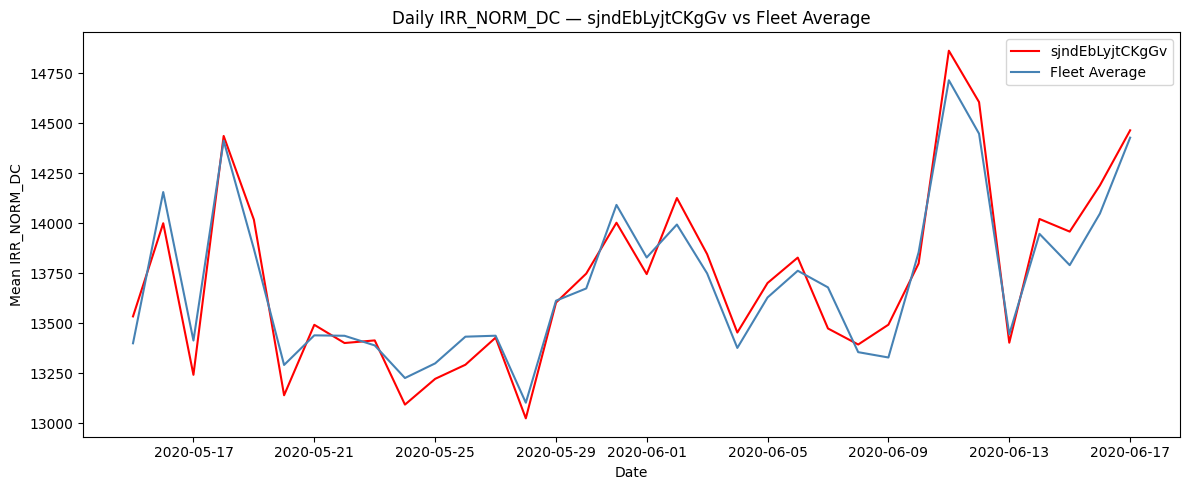

In [25]:
# Plot 1: Daily IRR_NORM_DC — target vs fleet
plt.figure(figsize=(12, 5))
plt.plot(daily_compare['DATE'], daily_compare['MEAN_IRR_NORM'],
         color='red', linewidth=1.5, label=TARGET)
plt.plot(daily_compare['DATE'], daily_compare['FLEET_IRR'],
         color='steelblue', linewidth=1.5, label='Fleet Average')
plt.title(f'Daily IRR_NORM_DC — {TARGET} vs Fleet Average')
plt.xlabel('Date')
plt.ylabel('Mean IRR_NORM_DC')
plt.legend()
plt.tight_layout()
plt.show()

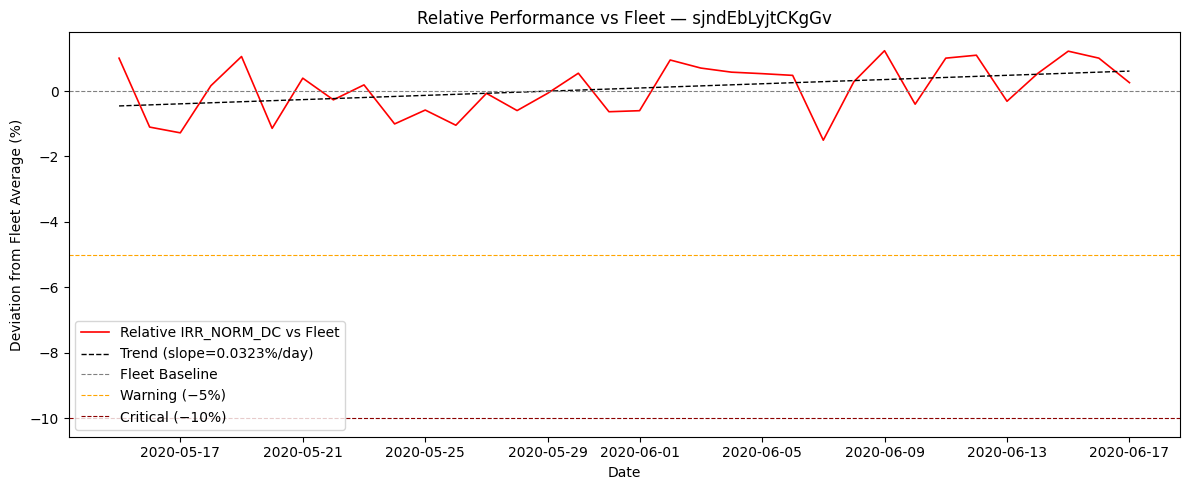

In [26]:
# Plot 2: Relative performance with trend line
trend_line = intercept + slope * x

plt.figure(figsize=(12, 5))
plt.plot(daily_compare['DATE'], daily_compare['REL_IRR_NORM'],
         color='red', linewidth=1.2, label='Relative IRR_NORM_DC vs Fleet')
plt.plot(daily_compare['DATE'], trend_line,
         color='black', linestyle='--', linewidth=1.0,
         label=f'Trend (slope={slope:.4f}%/day)')
plt.axhline(y=0,   color='gray',    linestyle='--', linewidth=0.8, label='Fleet Baseline')
plt.axhline(y=-5,  color='orange',  linestyle='--', linewidth=0.8, label='Warning (−5%)')
plt.axhline(y=-10, color='darkred', linestyle='--', linewidth=0.8, label='Critical (−10%)')
plt.title(f'Relative Performance vs Fleet — {TARGET}')
plt.xlabel('Date')
plt.ylabel('Deviation from Fleet Average (%)')
plt.legend()
plt.tight_layout()
plt.show()

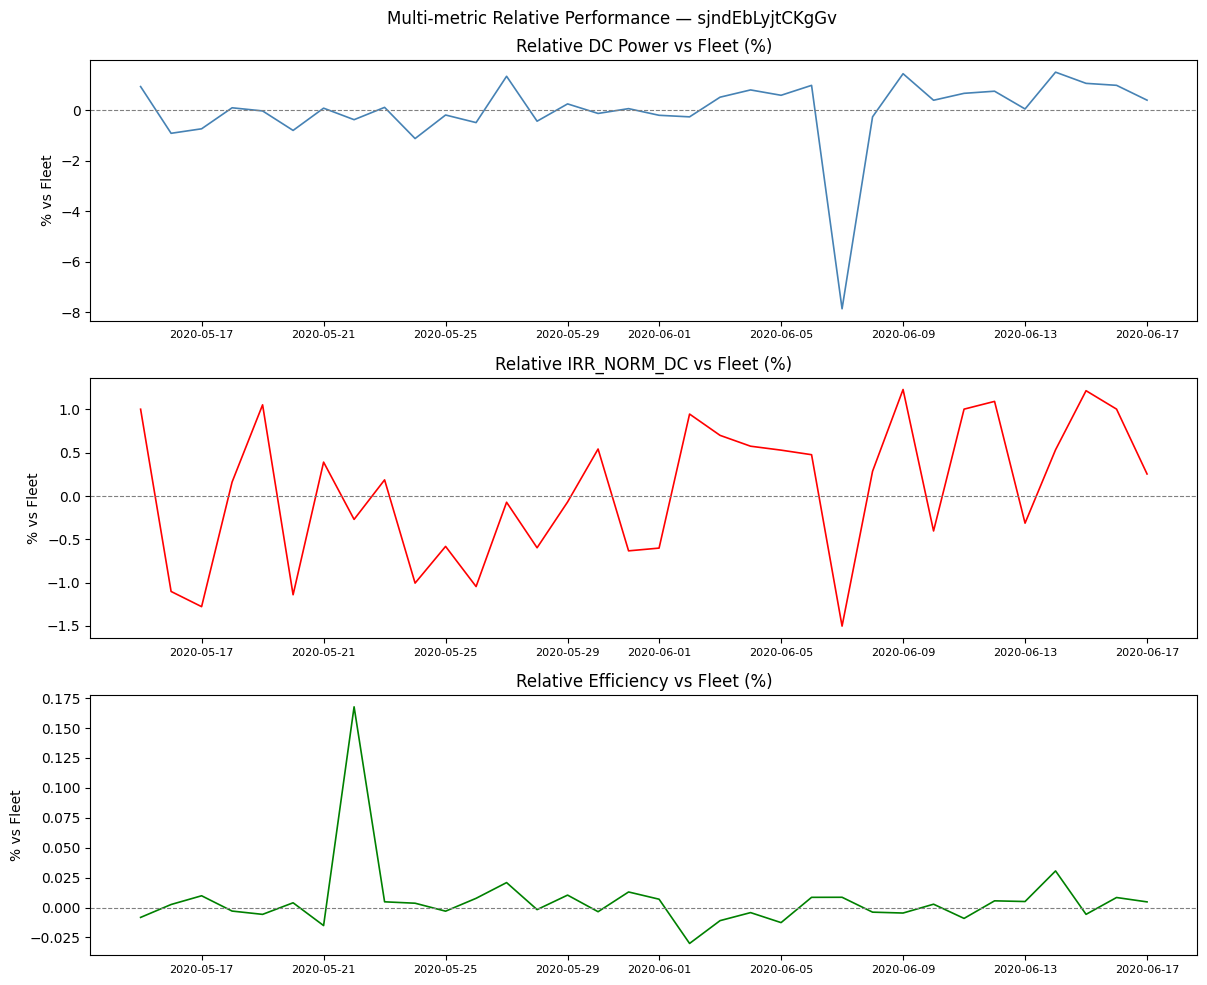

In [27]:
# Plot 3: Multi-metric relative performance
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
metrics = ['REL_DC', 'REL_IRR_NORM', 'REL_EFF']
titles  = ['Relative DC Power vs Fleet (%)',
           'Relative IRR_NORM_DC vs Fleet (%)',
           'Relative Efficiency vs Fleet (%)']
colors  = ['steelblue', 'red', 'green']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.plot(daily_compare['DATE'], daily_compare[metric], color=color, linewidth=1.2)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel('% vs Fleet')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle(f'Multi-metric Relative Performance — {TARGET}', fontsize=12)
plt.tight_layout()
plt.show()

---
## 8. Summary and Conclusions

### Model Comparison

| Method | Features | Issue | Anomaly Pattern |
|---|---|---|---|
| Baseline (2σ) | `EFFICIENCY_RATIO` per hour | Assumes normality | Hour-bucket deviations |
| IF V1 | DC, efficiency, derating, irradiation | Peak-hour bias | Flags high-irradiation peaks |
| **IF V2 ✓** | efficiency, IRR_NORM, derating, rolling deviation, time | None identified | Near-zero readings, actual shutdowns |

### Key Findings

1. **Fleet efficiency is stable** over the 35-day window (~0.9758–0.9783), with no systematic degradation.
2. **V1 peak-hour bias** was identified and corrected in V2 by removing correlated raw features and adding irradiation-normalized and time-contextual features.
3. **V2 anomaly pattern** shifts to near-zero DC readings, consistent with inverter shutdowns and ramp-up/ramp-down irregularities — more plausible fault signatures.
4. **Inverter `sjndEbLyjtCKgGv`** showed a positive performance trend (+0.0323%/day) relative to the fleet, remaining within warning thresholds throughout the observation window.

### Limitations

- **No ground truth labels** — validation is relative to the statistical baseline, not confirmed fault records.
- **Single plant, ~35 days** — generalization has not been tested.
- **Contamination assumed** — 1.57% matches baseline, not derived from domain fault frequency data.
- **`P_RATED` estimated** from historical data, not manufacturer specifications.

### Next Steps

- Extend analysis to Plant 2 for cross-plant validation
- Compare against labeled fault data if available
- Explore supervised models if fault labels can be sourced from domain experts